In [10]:
import pandas as pd
import numpy as np

df = pd.read_csv('diamonds_cleaned.csv',encoding='utf-8')

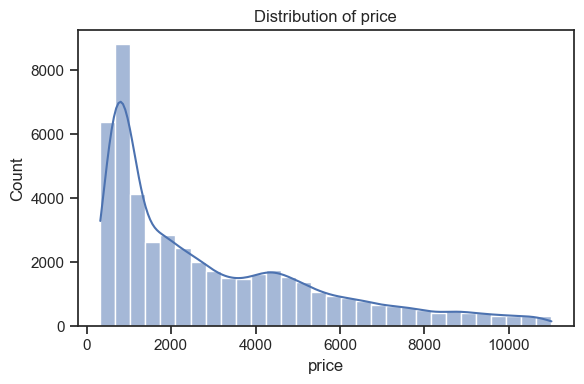

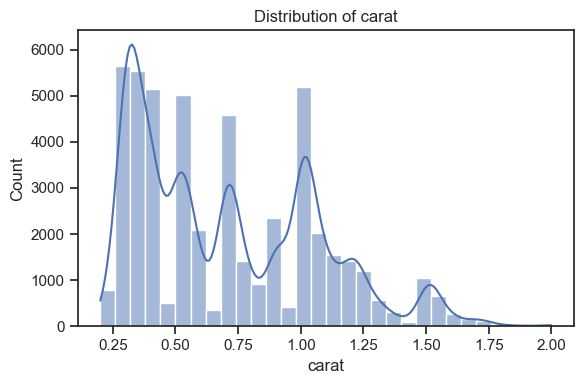

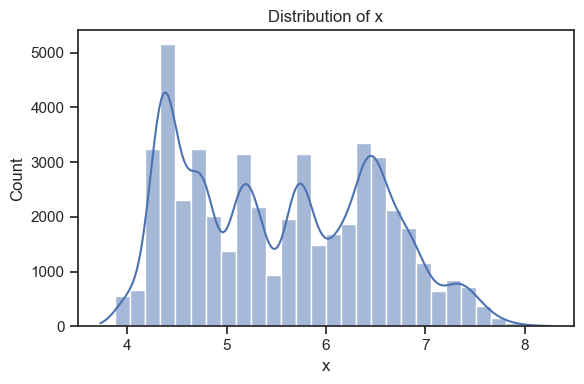

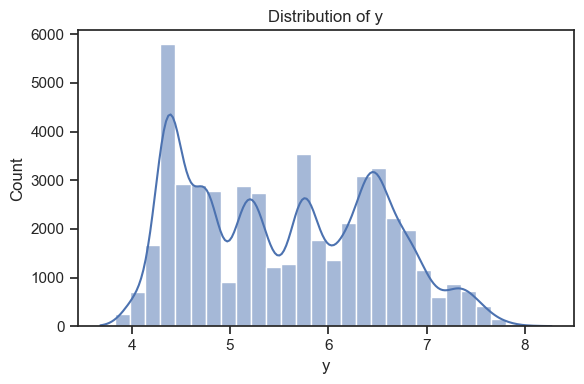

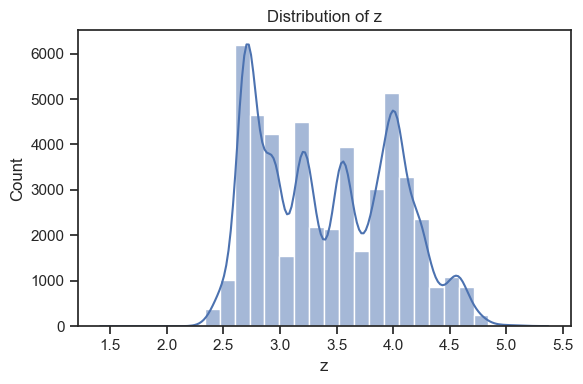

In [11]:
#Distribution Plots for Numerical Features

import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ['price', 'carat', 'x', 'y', 'z']
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=df, x=col, kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()


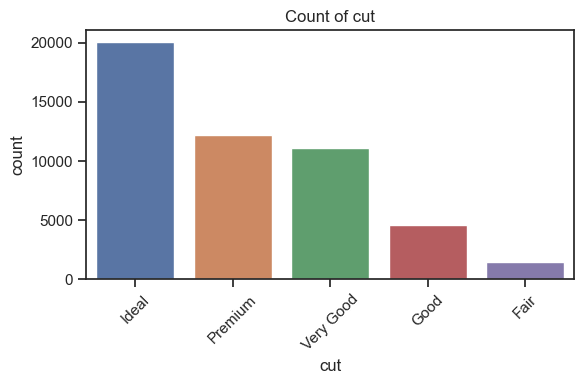

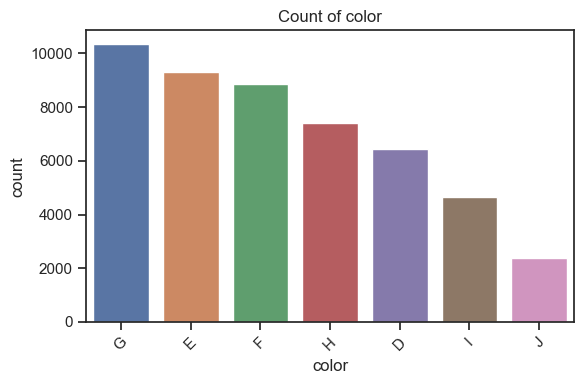

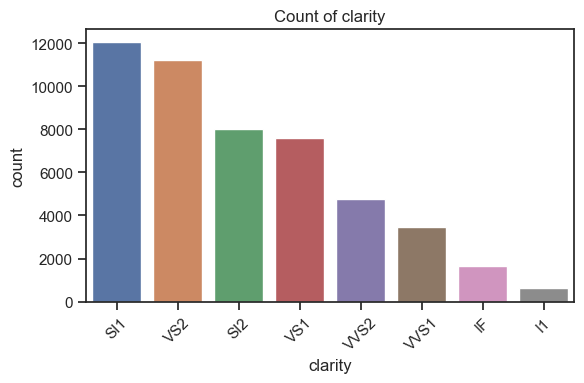

In [12]:
#Count Plots for Categorical Features

cat_cols = ['cut', 'color', 'clarity']
for col in cat_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f'Count of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


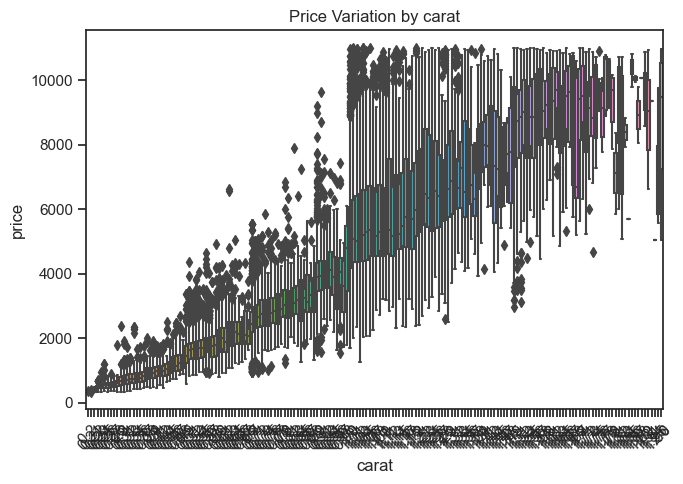

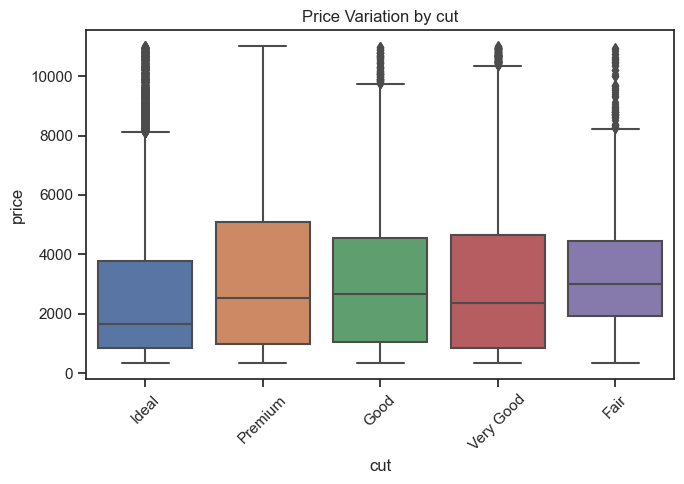

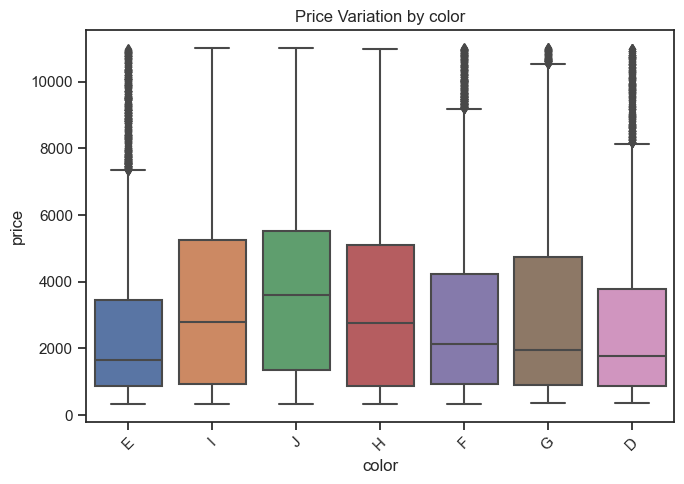

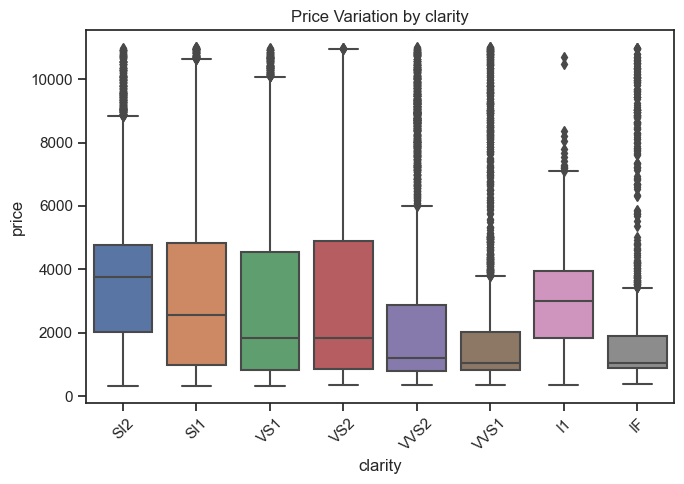

In [13]:
#Boxplots: Price Variation with Carat, Cut, Color, Clarity

for col in ['carat', 'cut', 'color', 'clarity']:
    plt.figure(figsize=(7, 5))
    sns.boxplot(data=df, x=col, y='price')
    plt.title(f'Price Variation by {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


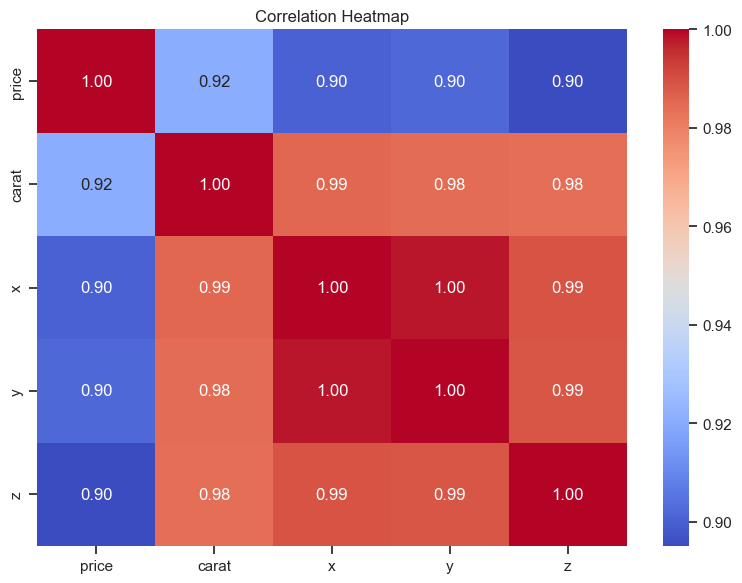

In [ ]:
#Correlation Heatmap for Numerical Features

plt.figure(figsize=(8, 6))
corr = df[['price', 'carat', 'x', 'y', 'z']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


                                           CORRELATION HEATMAP
1)Carat and price have a strong correlation of 0.92, confirming carat as the primary driver of price.

2)x, y, z are nearly perfectly correlated with each other (≥ 0.98), indicating they measure similar aspects of size.

3)Price also correlates highly with x, y, z (≈ 0.90), reinforcing that physical dimensions influence value.

4)Depth is excluded, likely due to its weak correlation — a good candidate for dimensionality reduction or separate treatment.

c:\Users\mural\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


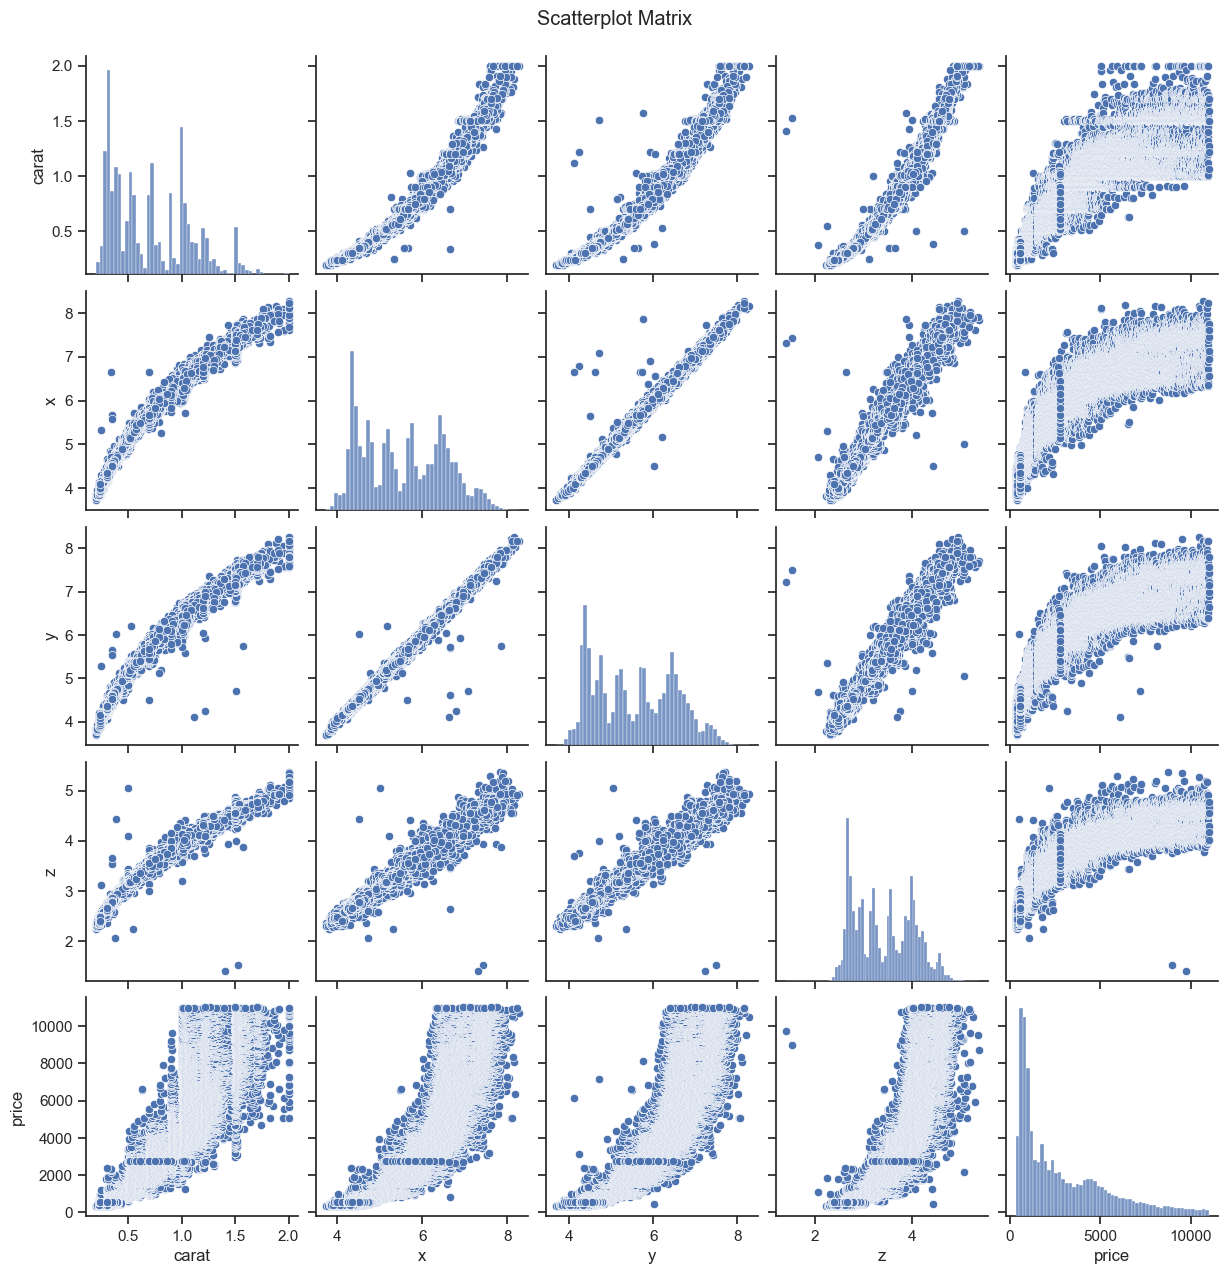

In [15]:
#Scatterplot Matrix for carat, x, y, z, price

sns.set(style="ticks")
sns.pairplot(df[['carat', 'x', 'y', 'z', 'price']])
plt.suptitle('Scatterplot Matrix', y=1.02)
plt.show()


                                        SCATTERPLOT MATRIX
1)This matrix visually confirms the strong linear relationships between carat, x, y, z, and price.

2)Histograms on the diagonal show right-skewed distributions for carat and price — consistent with earlier plots.

3)Scatterplots show tight clustering for x vs y, y vs z, etc., reinforcing multicollinearity among size dimensions.

4)Price vs. other features shows more spread, especially at higher values — again suggesting the need for transformation or segmentation.

c:\Users\mural\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


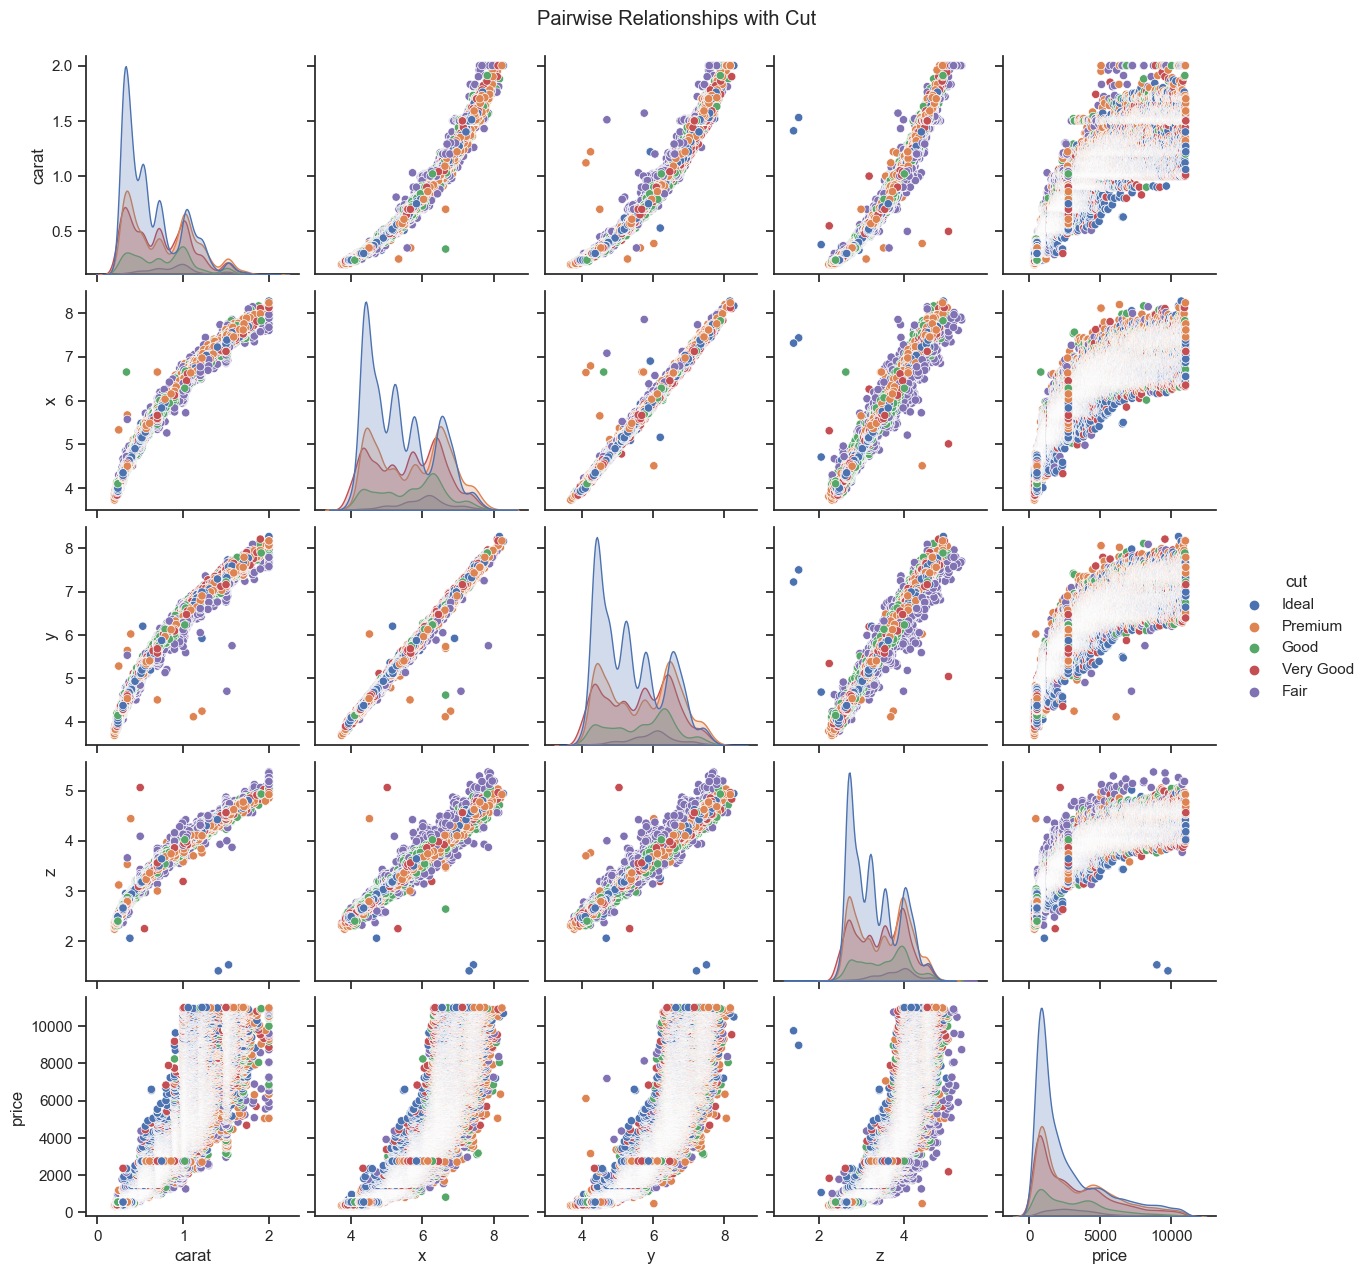

In [ ]:
#Pairwise Relationships using pairplot

sns.pairplot(df, vars=['carat', 'x', 'y', 'z', 'price'], hue='cut')
plt.suptitle('Pairwise Relationships with Cut', y=1.02)
plt.show()


1)This plot reveals how diamond features (carat, x, y, z, depth, price) vary across different cut qualities.

2)Carat, x, y, z show strong positive relationships with price — larger diamonds tend to be more expensive.

3)Cut quality influences price: Ideal and Premium cuts cluster at higher price ranges even for similar carat values.

4)Depth appears less correlated with other features and shows more uniform distribution across cuts.

5)Histograms show right-skewed distributions for carat and price, indicating many small, affordable diamonds and few large, expensive ones

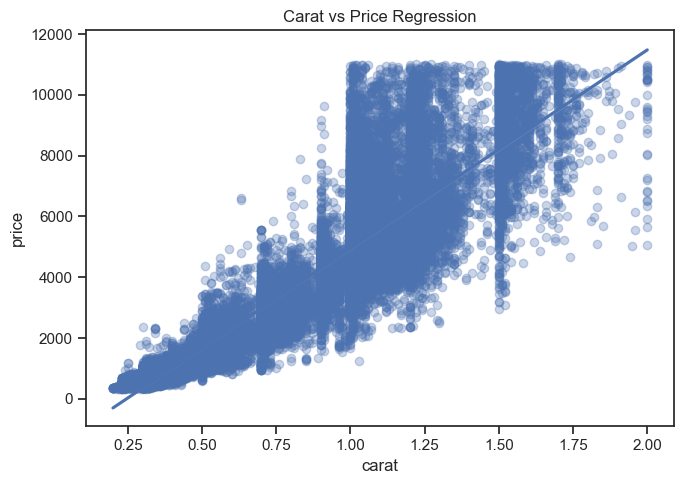

In [17]:
#Carat vs. Price Regression Lineplot

plt.figure(figsize=(7, 5))
sns.regplot(data=df, x='carat', y='price', scatter_kws={'alpha':0.3})
plt.title('Carat vs Price Regression')
plt.tight_layout()
plt.show()


1)A clear positive linear trend: as carat increases, price rises.

2)The regression line captures the general pattern, but there's increasing variance at higher carat — price becomes less predictable.

3)This suggests heteroscedasticity, which may affect regression modeling. A log transformation of price could help stabilize variance.

4)Outliers are visible: some diamonds with similar carat have very different prices, likely due to cut, clarity, or color.

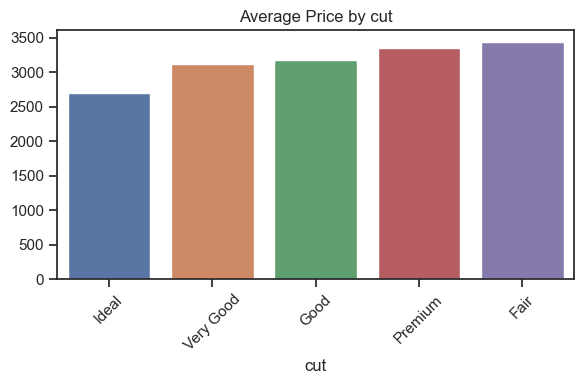

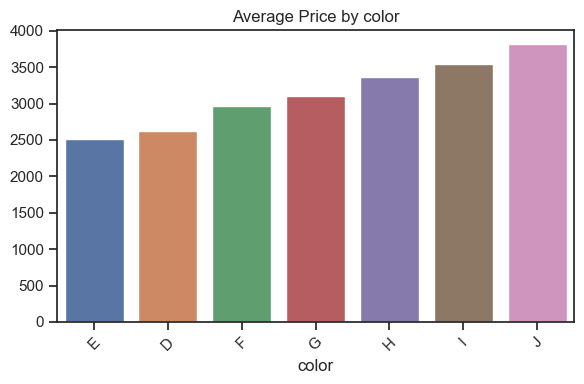

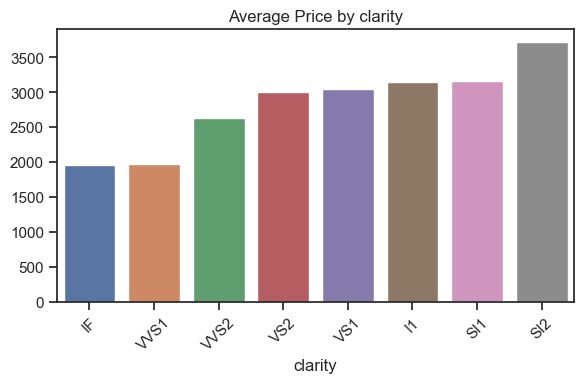

In [18]:
#Average Price per Cut, Color, Clarity

for col in ['cut', 'color', 'clarity']:
    plt.figure(figsize=(6, 4))
    avg_price = df.groupby(col)['price'].mean().sort_values()
    sns.barplot(x=avg_price.index, y=avg_price.values)
    plt.title(f'Average Price by {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
